In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('cardiotocographic.csv')
data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
data.info()
data.shape
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [4]:
data.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [5]:
data = data.fillna(data.median(numeric_only=True))

In [6]:
data.dtypes
data['LB'] = pd.to_numeric(data['LB'], errors='coerce')

In [7]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)

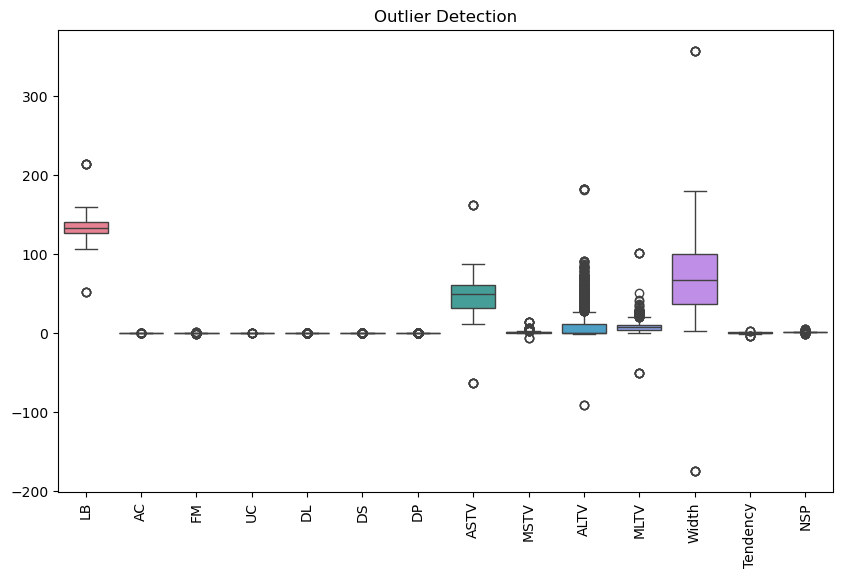

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()


In [9]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]


In [10]:
data.describe()
data.median()
data.std()
data.quantile([0.25, 0.75])

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0.25,125.0,0.000021,0.000000,0.003170,0.000000,0.0,0.0,29.0,0.9,0.0,5.6,41.5,0.0,1.0
0.75,138.0,0.006673,0.000336,0.006931,0.003084,0.0,0.0,56.0,1.6,4.0,11.3,92.0,1.0,1.0


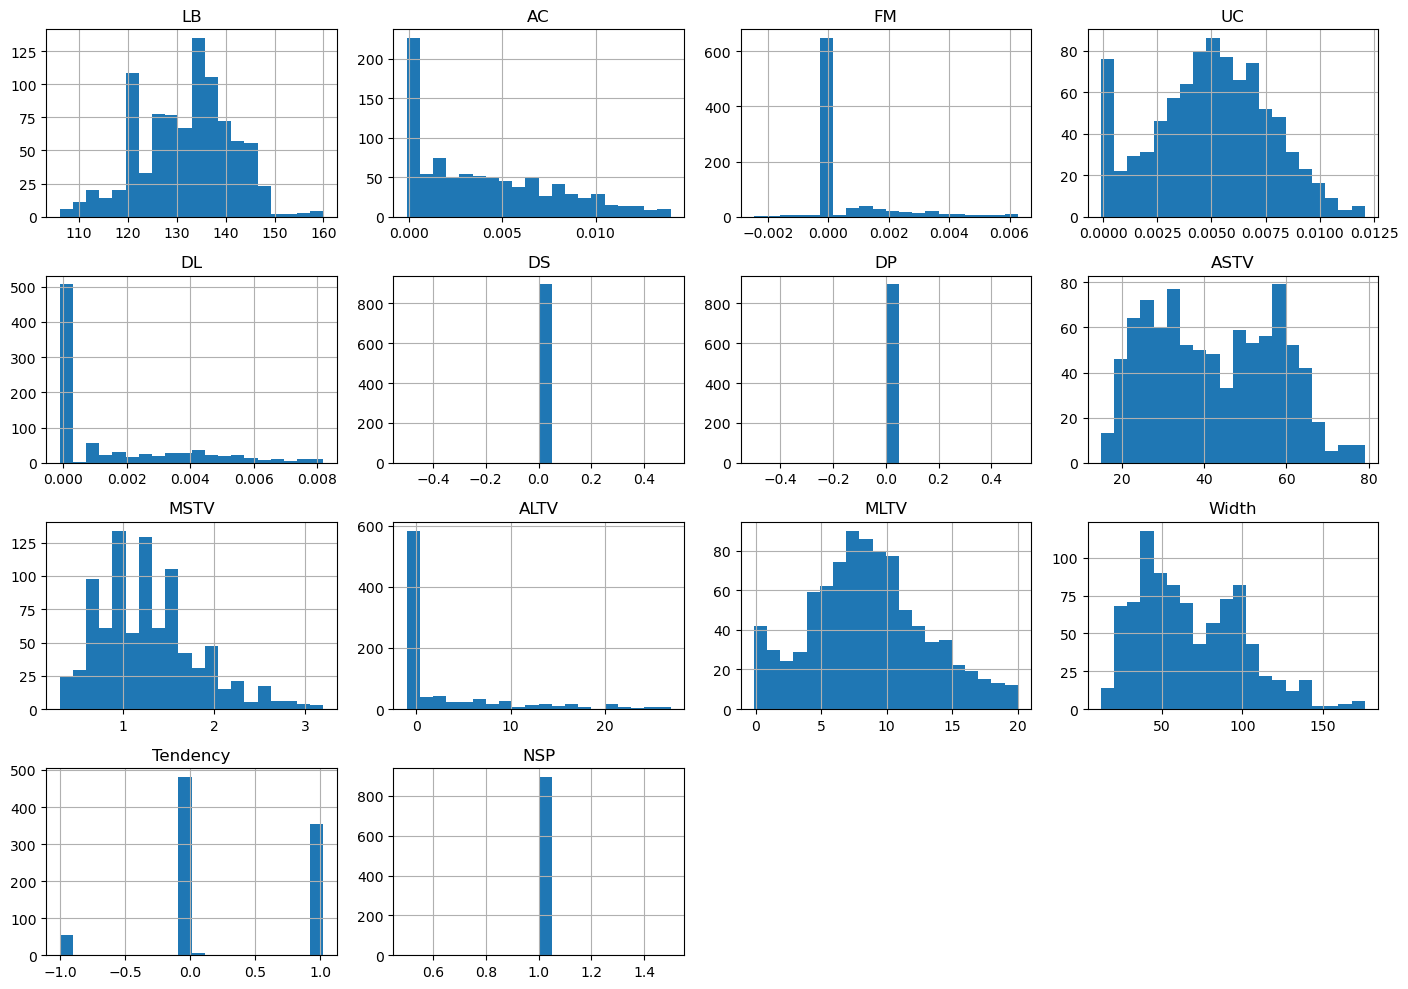

In [11]:
data.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

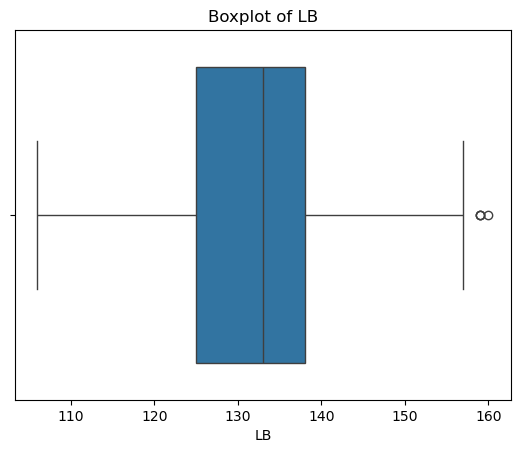

<Figure size 1000x800 with 0 Axes>

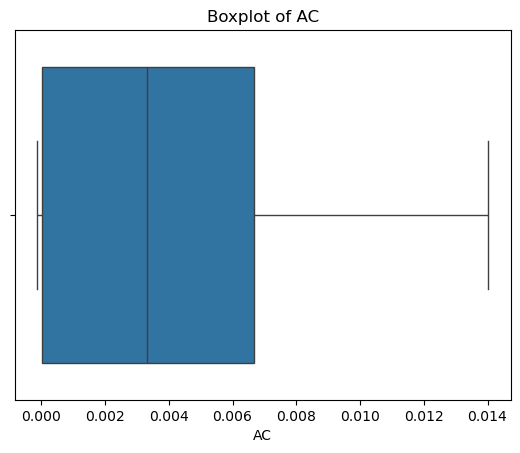

<Figure size 1000x800 with 0 Axes>

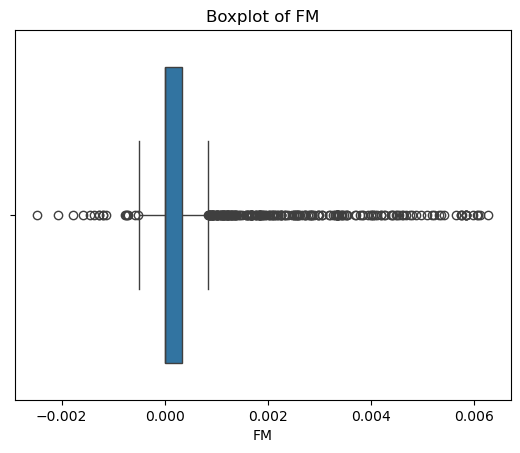

<Figure size 1000x800 with 0 Axes>

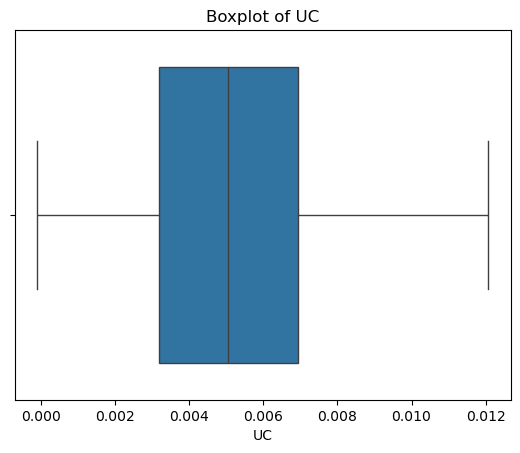

<Figure size 1000x800 with 0 Axes>

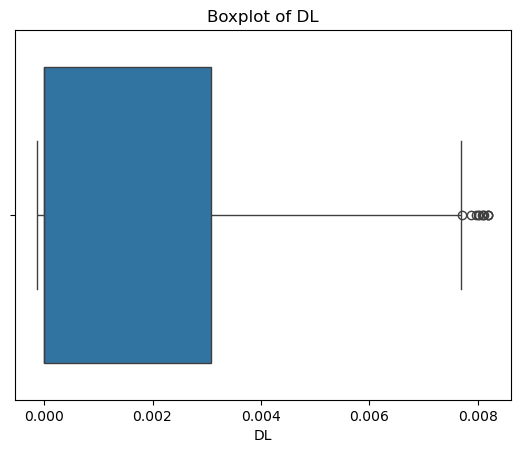

<Figure size 1000x800 with 0 Axes>

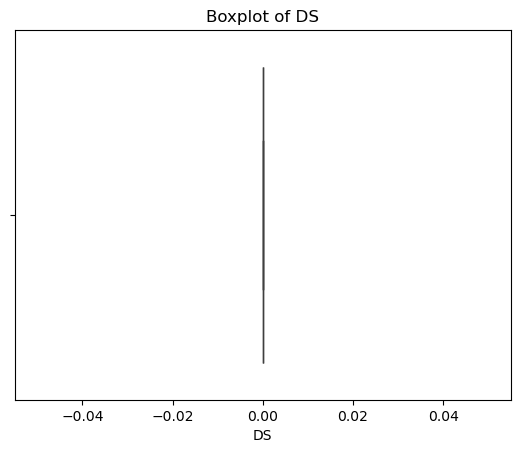

<Figure size 1000x800 with 0 Axes>

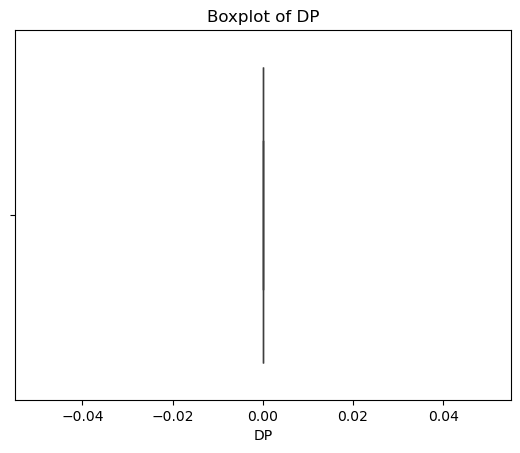

<Figure size 1000x800 with 0 Axes>

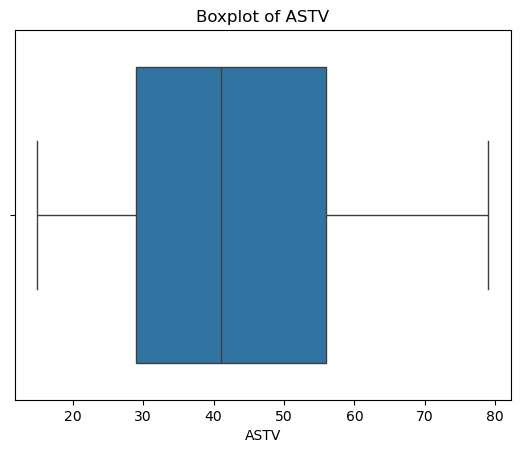

<Figure size 1000x800 with 0 Axes>

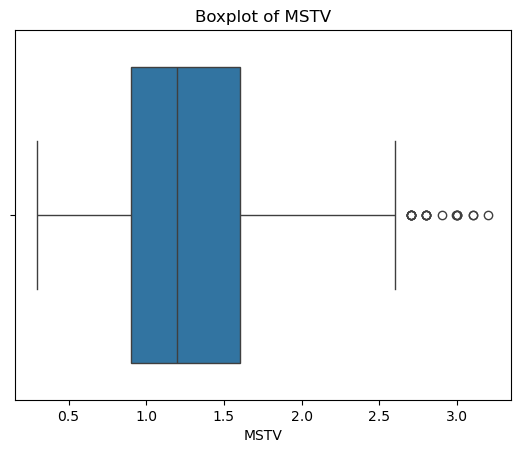

<Figure size 1000x800 with 0 Axes>

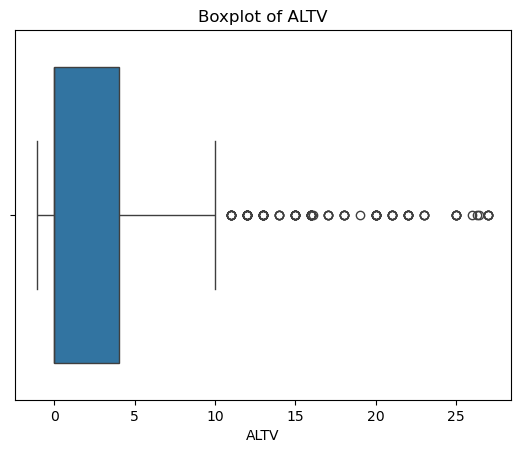

<Figure size 1000x800 with 0 Axes>

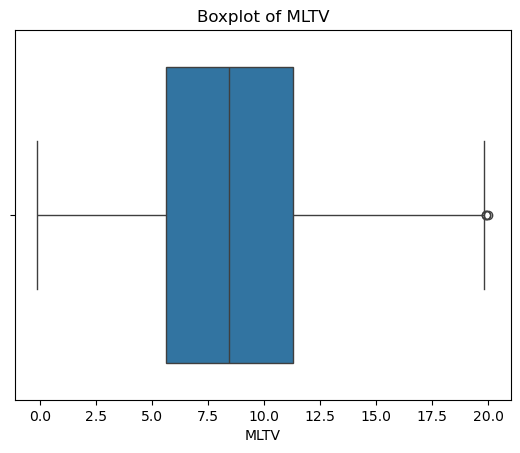

<Figure size 1000x800 with 0 Axes>

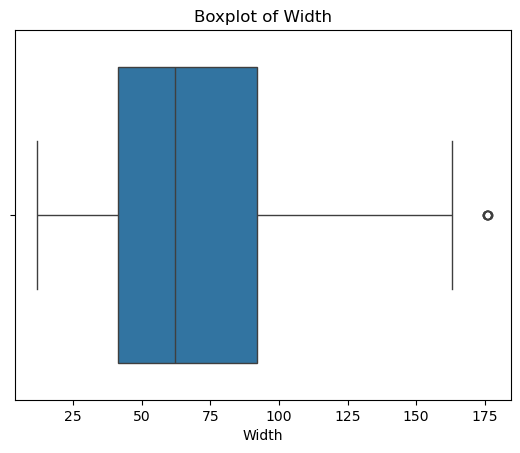

<Figure size 1000x800 with 0 Axes>

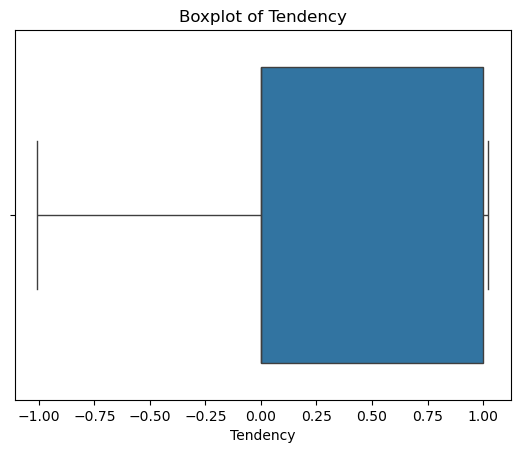

<Figure size 1000x800 with 0 Axes>

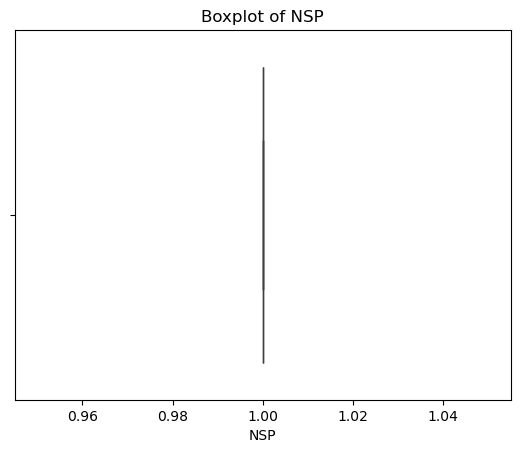

In [20]:
for col in data.columns:
    plt.figure(figsize=(10,8))
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

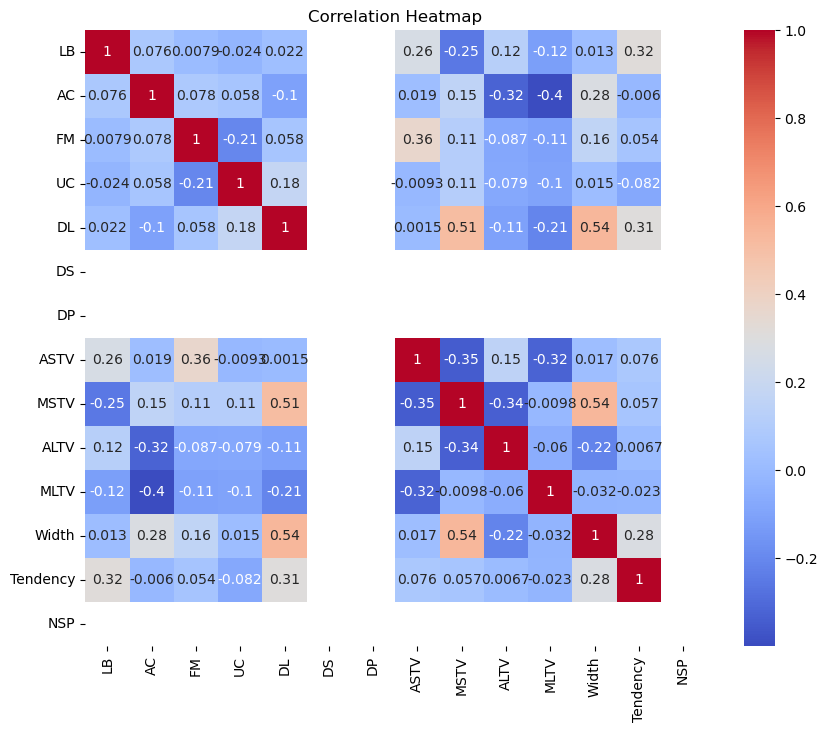

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

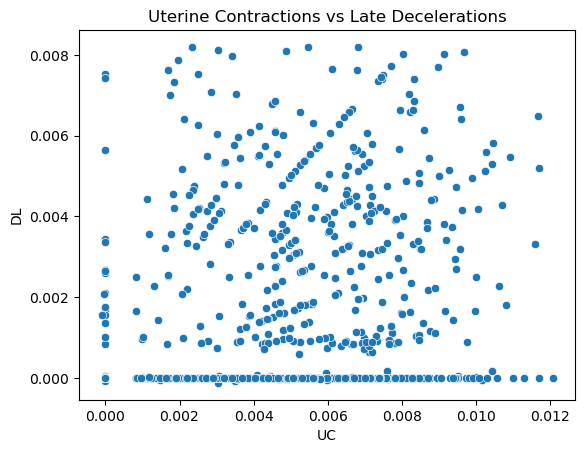

In [22]:
sns.scatterplot(x='UC', y='DL', data=data)
plt.title("Uterine Contractions vs Late Decelerations")
plt.show()

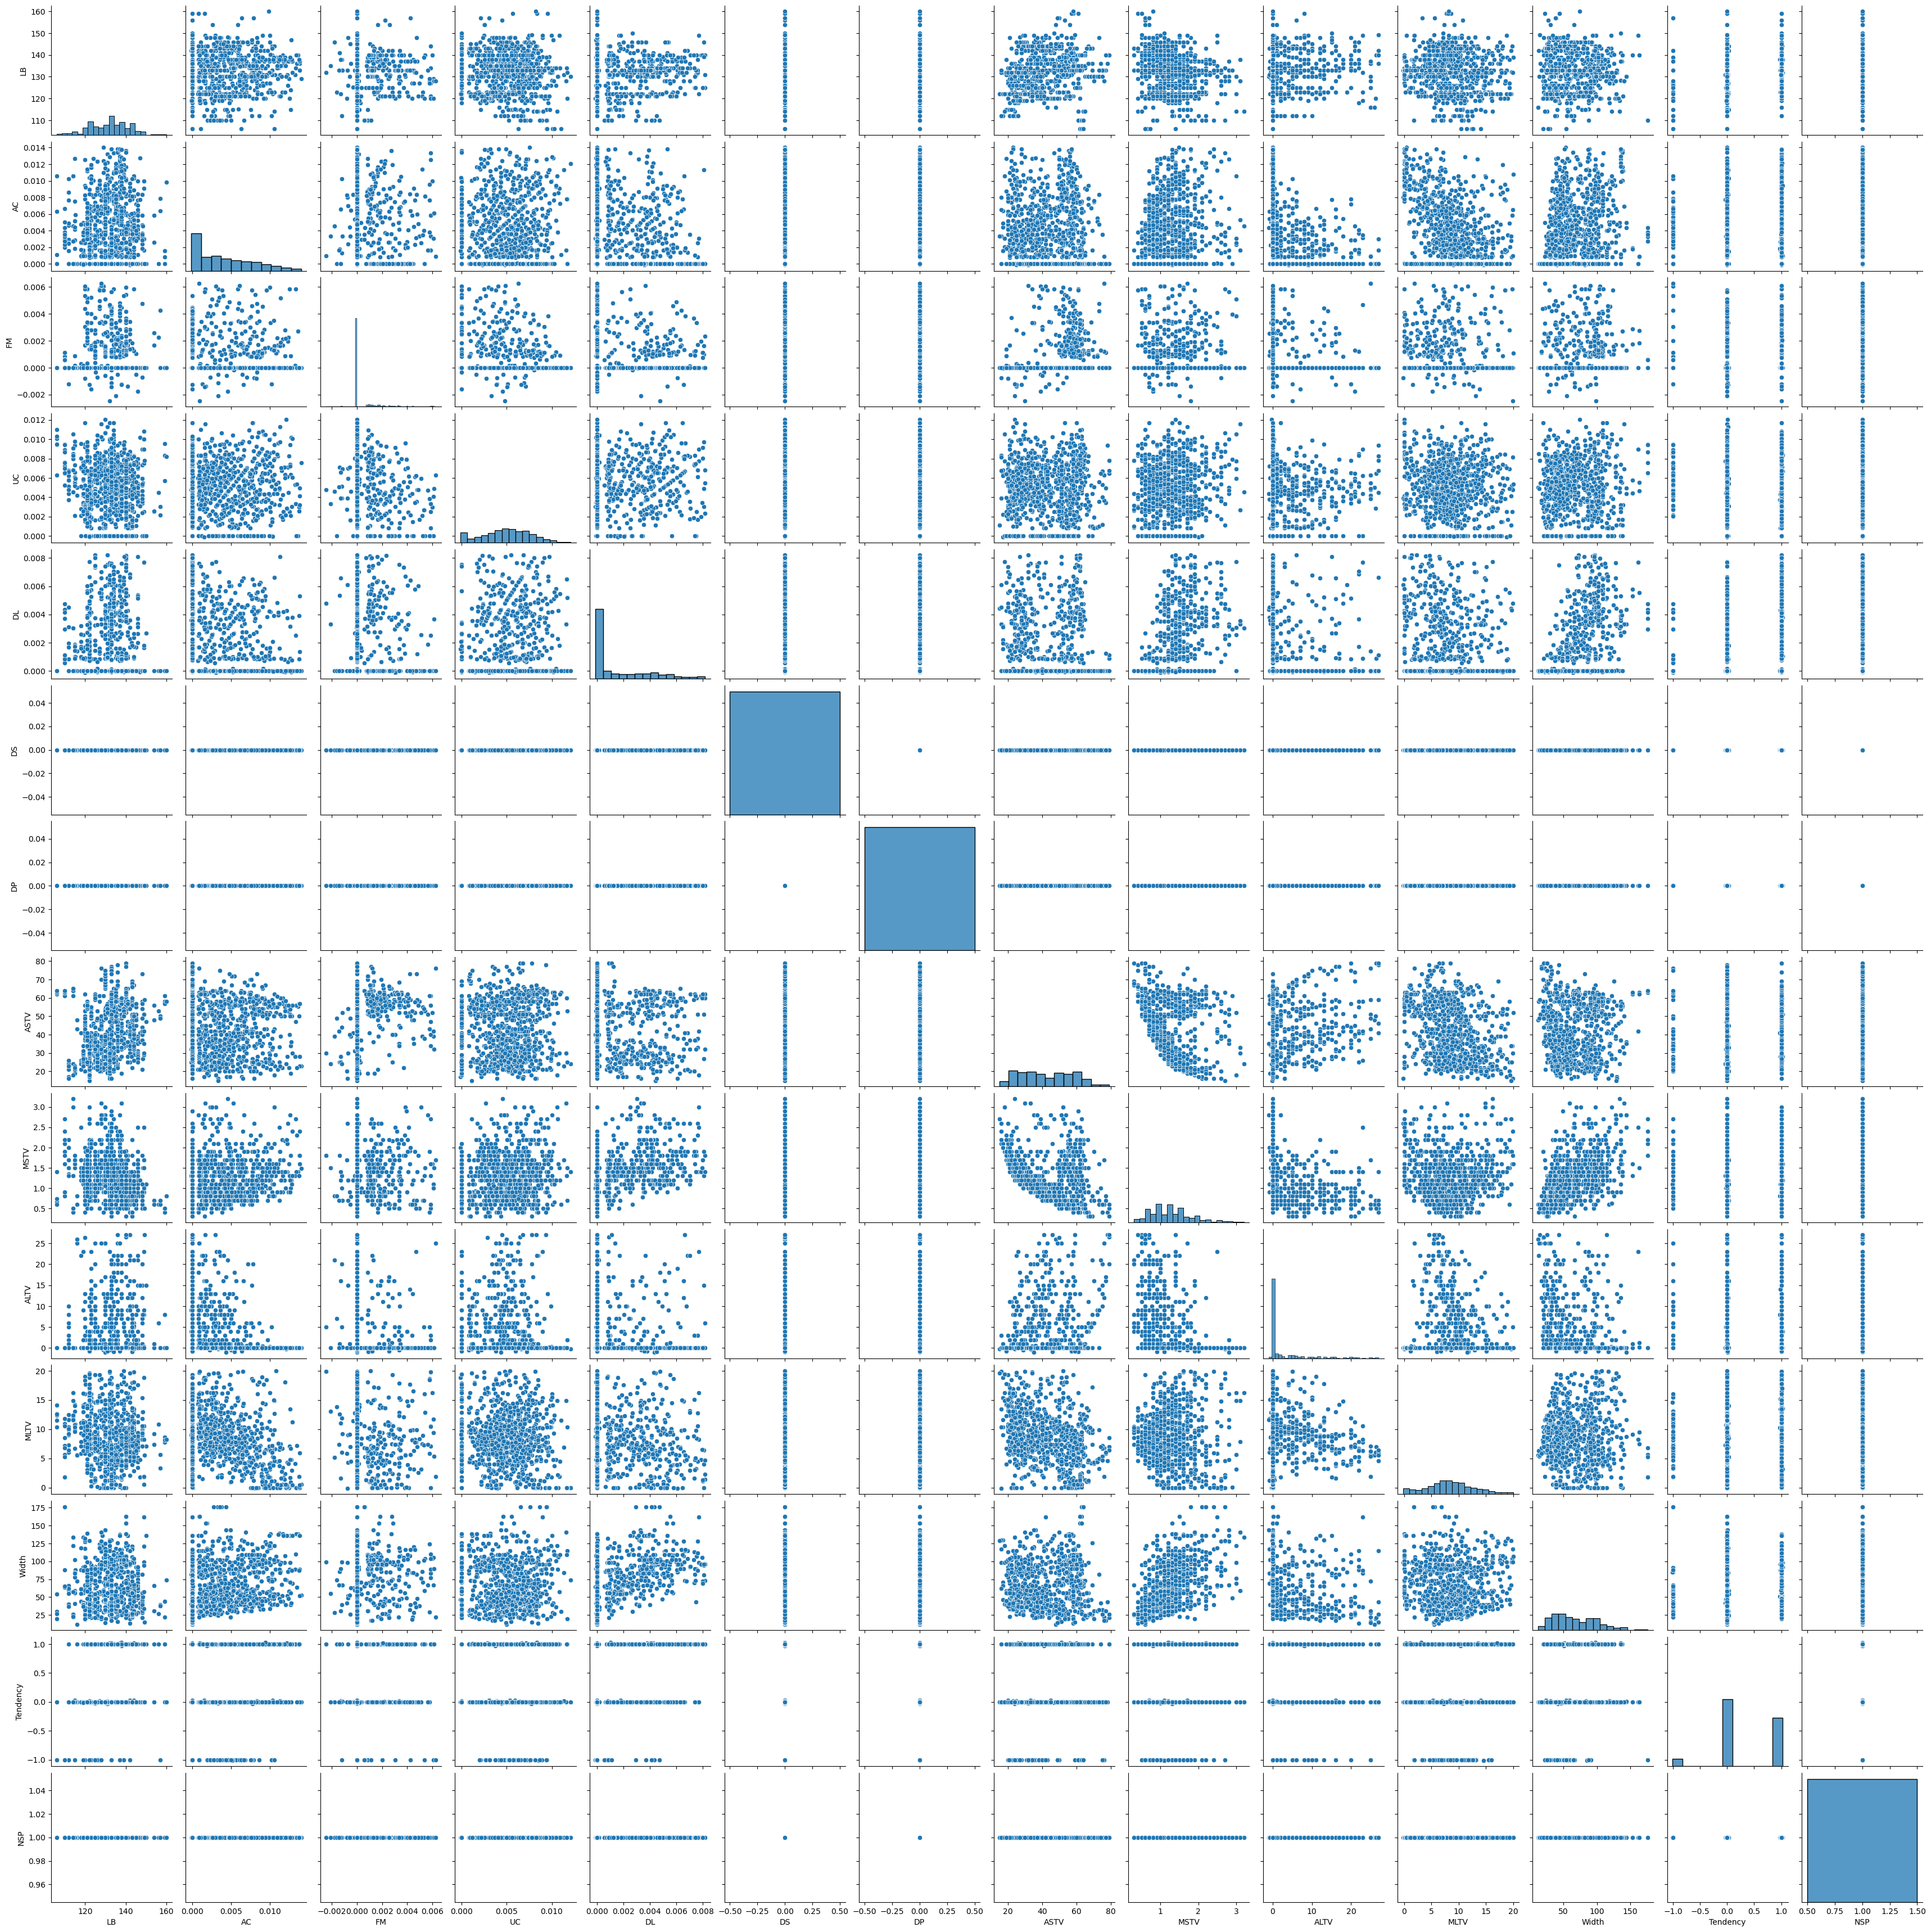

In [26]:
sns.pairplot(data)
plt.show()

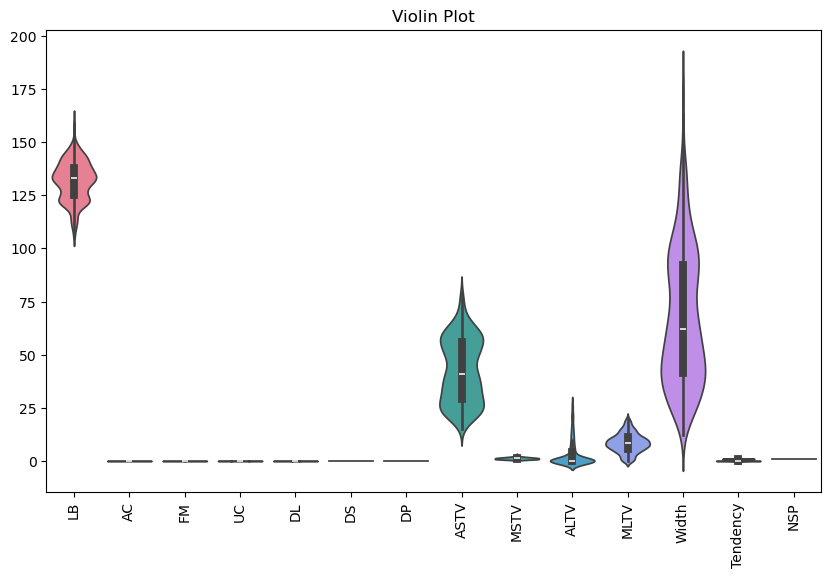

In [27]:
plt.figure(figsize=(10,6))
sns.violinplot(data=data)
plt.xticks(rotation=90)
plt.title("Violin Plot")
plt.show()

In [28]:
corr = data.corr()
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,0.075840,0.007870,-0.024292,0.021620,NaN,NaN,0.262344,-0.253132,0.124672,-0.117551,0.012845,0.315557,NaN
AC,0.075840,1.000000,0.078089,0.058031,-0.104355,NaN,NaN,0.018538,0.154547,-0.324367,-0.399255,0.278869,-0.006035,NaN
FM,0.007870,0.078089,1.000000,-0.207295,0.058147,NaN,NaN,0.362614,0.113580,-0.087467,-0.108788,0.159351,0.053528,NaN
UC,-0.024292,0.058031,-0.207295,1.000000,0.175150,NaN,NaN,-0.009296,0.112453,-0.078789,-0.102655,0.015491,-0.081691,NaN
DL,0.021620,-0.104355,0.058147,0.175150,1.000000,NaN,NaN,0.001472,0.510083,-0.107918,-0.211144,0.537059,0.309206,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.262344,0.018538,0.362614,-0.009296,0.001472,NaN,NaN,1.000000,-0.346515,0.150406,-0.324859,0.016757,0.075850,NaN
MSTV,-0.253132,0.154547,0.113580,0.112453,0.510083,NaN,NaN,-0.346515,1.000000,-0.336172,-0.009847,0.538891,0.057162,NaN
ALTV,0.124672,-0.324367,-0.087467,-0.078789,-0.107918,NaN,NaN,0.150406,-0.336172,1.000000,-0.059865,-0.215952,0.006651,NaN


In [ ]:
#1.In the notebook, I did the following

Loaded the dataset using pandas
Checked basic details like shape, data types, and summary statistics
Checked for missing values and handled them using median imputation
Removed duplicate rows
Converted columns to correct data types where needed
For analysis and visualization:
Used histograms to see data distribution
Used boxplots to detect outliers
Removed outliers using the IQR method
Created a correlation heatmap to see relationships between variables
Plotted scatter plot
Used pairplot and violin plots for deeper understanding

#2.brief Report
Objective

The main aim of this analysis was to understand the dataset and find patterns related to fetal health indicators
Findings
Some columns had missing values, which were filled using median
Outliers were present and removed using IQR method
Most variables have a normal distribution, but some are slightly skewed
There is a relationship between uterine contractions (UC) and decelerations (DL)

Insights
Higher uterine contractions may be linked with fetal stress
Variability features (ASTV, MSTV, etc.) are important for understanding fetal condition
Some variables are strongly related, which can help in prediction

Recommendations
Use machine learning models to predict fetal health (NSP)
Select important features for better model performance
Do more advanced analysis if needed

Conclusion
This EDA helped in understanding the dataset clearly.
It showed important patterns and relationships between variables, which can be useful for further analysis and prediction of fetal health.